In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = 'whitegrid')

In [ ]:
import pandas as pd
# Choose the used-cars CSV file from your computer
from google.colab import files

uploaded = files.upload()
csv_file = next(iter(uploaded))
df = pd.read_csv(csv_file)

print('Shape:', df.shape)
df.head()

Saving Heart Attack.csv to Heart Attack.csv
Shape: (1319, 9)


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1319 non-null   int64  
 1   gender         1319 non-null   int64  
 2   impluse        1319 non-null   int64  
 3   pressurehight  1319 non-null   int64  
 4   pressurelow    1319 non-null   int64  
 5   glucose        1319 non-null   float64
 6   kcm            1319 non-null   float64
 7   troponin       1319 non-null   float64
 8   class          1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
impluse,0
pressurehight,0
pressurelow,0
glucose,0
kcm,0
troponin,0
class,0


In [ ]:
numeric_cols = df.select_dtypes(include = "number")
print(numeric_cols)

      age  gender  impluse  pressurehight  pressurelow  glucose    kcm  \
0      64       1       66            160           83    160.0   1.80   
1      21       1       94             98           46    296.0   6.75   
2      55       1       64            160           77    270.0   1.99   
3      64       1       70            120           55    270.0  13.87   
4      55       1       64            112           65    300.0   1.08   
...   ...     ...      ...            ...          ...      ...    ...   
1314   44       1       94            122           67    204.0   1.63   
1315   66       1       84            125           55    149.0   1.33   
1316   45       1       85            168          104     96.0   1.24   
1317   54       1       58            117           68    443.0   5.80   
1318   51       1       94            157           79    134.0  50.89   

      troponin  
0        0.012  
1        1.060  
2        0.003  
3        0.122  
4        0.003  
...      

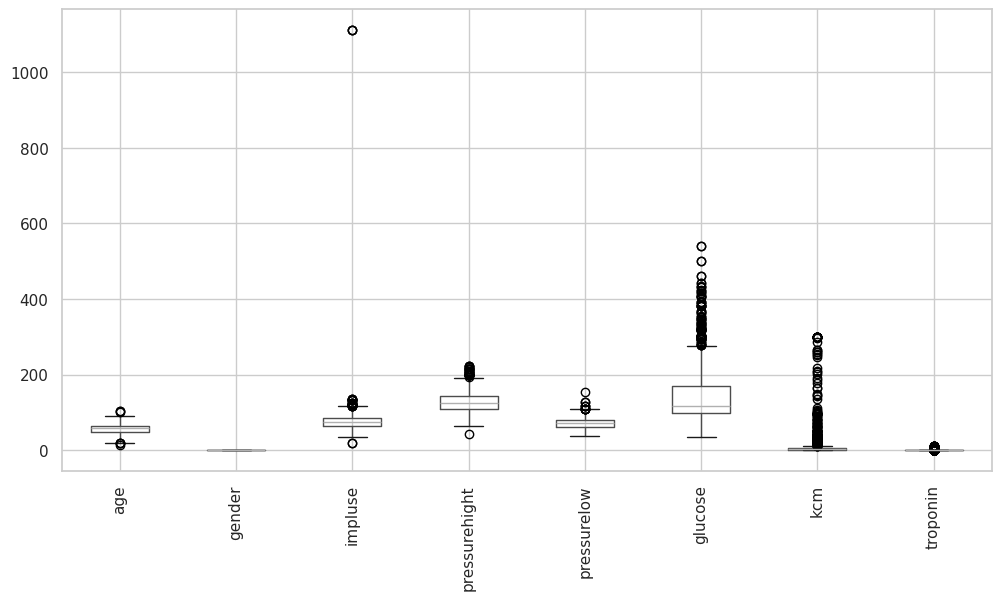

In [ ]:
numeric_cols.boxplot(figsize =(12,6))
plt.xticks(rotation = 90)
plt.show()

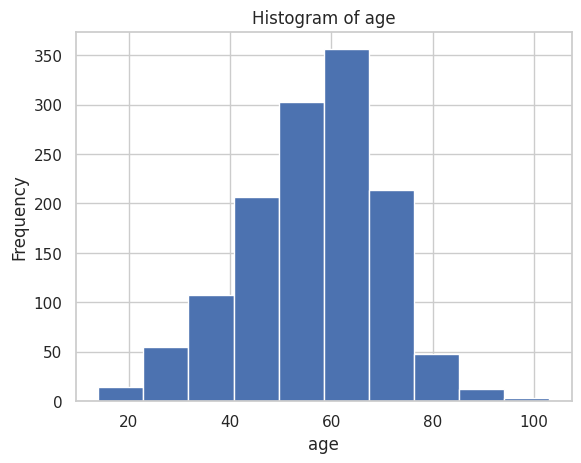

In [ ]:
#Univariate
import matplotlib.pyplot as plt
df["age"].hist(bins = 10)
plt.title("Histogram of age")
plt.xlabel("age")
plt.ylabel("Frequency")
plt.show()


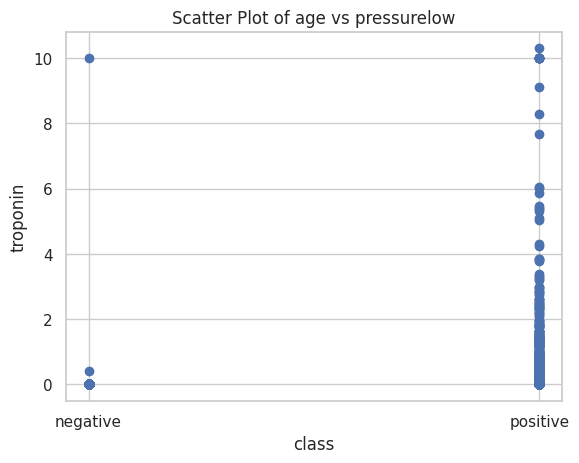

In [ ]:
#Bivariate
plt.scatter(df["class"], df["troponin"])
plt.title("Scatter Plot of age vs pressurelow")
plt.xlabel("class")
plt.ylabel("troponin")
plt.show()

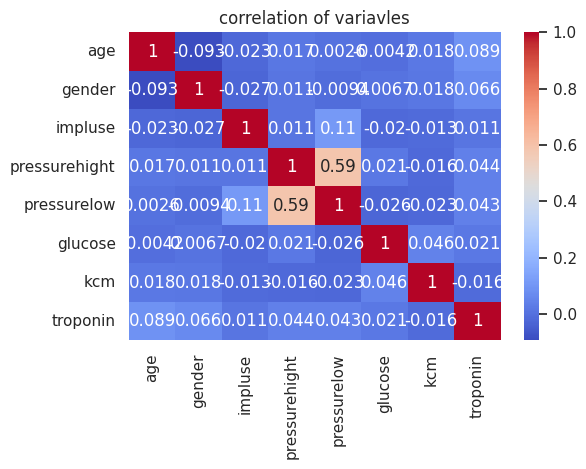

In [ ]:
#Heatmap
corr = df.corr(numeric_only = True)
plt.figure(figsize = (6,4))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title("correlation of variavles")
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv('Heart Attack.csv')

df['class'] = df['class'].map({
    'positive': 1,
    'negative': 0
})

print(df['class'].value_counts(dropna=False))
print(df['class'].dtype)

class
1    810
0    509
Name: count, dtype: int64
int64


In [ ]:
df["class"].dtype

dtype('int64')

In [ ]:
# x & y separation
X = df.drop(columns = ["class"])
y = df["class"]

In [ ]:
X.head()

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
0,64,1,66,160,83,160.0,1.80,0.012
1,21,1,94,98,46,296.0,6.75,1.060
2,55,1,64,160,77,270.0,1.99,0.003
3,64,1,70,120,55,270.0,13.87,0.122
4,55,1,64,112,65,300.0,1.08,0.003


In [ ]:
y.head()

,class
0,0
1,1
2,0
3,1
4,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1055, 8), (264, 8), (1055,), (264,))

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([1.41741061, 0.29680738, 0.56899627, 0.31010226, 0.37383086,
       0.66522179, 0.68279972, 0.63387842, 0.64643789, 0.62652822,
       0.34399144, 0.25570068, 0.60461387, 1.28902142, 0.53109831,
       0.44411099, 0.71946472, 0.61839796, 0.5769483 , 0.42678693,
       0.62910991, 0.74180015, 0.51501209, 0.34809589, 0.58097568,
       0.24702009, 0.62062977, 0.73546076, 0.88205664, 0.37894494,
       0.25254097, 0.63160862, 0.87639686, 0.6062343 , 0.42152731,
       0.54551287, 0.94012245, 0.79879212, 0.39336862, 0.80490154,
       0.72747307, 0.42451566, 0.81977009, 0.56025173, 0.68167239,
       0.6803018 , 0.63205666, 0.59302911, 0.34539552, 0.49558097,
       0.28406173, 0.59556301, 0.59856604, 0.50594404, 0.3478804 ,
       0.55337969, 0.6913999 , 0.76470873, 0.49874064, 0.59876925,
       0.30235568, 0.61698154, 0.72910345, 0.51145902, 0.61500615,
       0.83744474, 0.65626244, 0.65943007, 0.45513961, 0.66025381,
       0.49198643, 0.74330937, 0.63837526, 0.70544842, 0.52157

In [ ]:
comparsion = pd.DataFrame({"Actual": y_test, "predicted": y_pred})
comparsion.head(10)

,Actual,predicted
677,1,1.417411
1046,0,0.296807
610,0,0.568996
49,0,0.310102
1284,1,0.373831
486,1,0.665222
548,1,0.682800
939,1,0.633878
78,1,0.646438
506,1,0.626528


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)

Mean Squared Error: 0.2101596208141232
Mean Absolute Error: 0.42635059710478884
R-squared: 0.11029065587917586


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1319 non-null   int64  
 1   gender         1319 non-null   int64  
 2   impluse        1319 non-null   int64  
 3   pressurehight  1319 non-null   int64  
 4   pressurelow    1319 non-null   int64  
 5   glucose        1319 non-null   float64
 6   kcm            1319 non-null   float64
 7   troponin       1319 non-null   float64
 8   class          1319 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 92.9 KB


In [90]:
new_data = pd.DataFrame({
    'age': [64, 21],
    'gender': [1, 1],
    'impluse': [66, 94],
    'pressurehight': [160, 98],
    'pressurelow': [83, 46],
    'glucose': [160.0, 296.0],
    'kcm': [1.80, 6.75],
    'troponin': [0.012, 1.060]
})
new_data_scaled = scaler.transform(new_data)
predicted_performance = model.predict(new_data_scaled)
print("Predicated Performance index:", predicted_performance[0])

Predicated Performance index: 0.6365489004763731


In [91]:
print("coeffiecents:",model.coef_)
print("intercept:",model.intercept_)

coeffiecents: [ 0.10978466  0.05996402  0.00086963 -0.01736355  0.00736333 -0.02481044
  0.10637443  0.10512907]
intercept: 0.6132701421800948


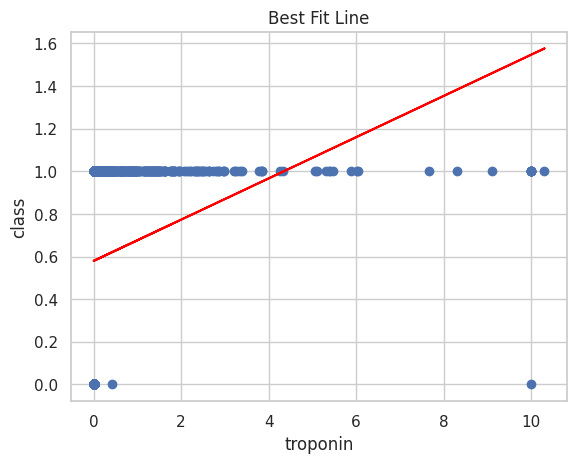

In [95]:
#best fit line
plt.scatter(df['troponin'], df['class'])
m, c = np.polyfit(df['troponin'], df['class'], 1)
plt.plot(
    df['troponin'],
    m * df['troponin'] + c,
    color='red'
)

plt.xlabel('troponin')
plt.ylabel('class')
plt.title('Best Fit Line')
plt.show()